Estudos sobre a extração de dados de arquivos hiperespectrais usando a biblioteca spectral

In [1]:
from spectral import imshow, get_rgb
import spectral.io.envi as envi
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import pandas as pd
from scipy import ndimage
import gc  # Para liberar memória
from matplotlib.patches import Rectangle

## Reading the hypersperspectral image


The hyperspectral image needs three different images to get a corrected image — raw data (raw reflectance values from the camera), *white_ref* - which is the reflectance from white calibration surface, and *dark_ref* - the refelctance from dark (usually zeros). The white and dark references are used to calibrate and normalise the raw refelctance values using the equation:
$$
\begin {equation}

CorrectedImage = \frac{RawReflectance - DarkReflectance}{WhiteReflectance - DarkReflectance}

\end{equation}
$$



In [2]:
dark_ref = envi.open(r'C:\Users\vabath\OneDrive - Firjan\Hiper_temp\Sample\AUP_Ca_20ppm_1\capture\DARKREF_AUP_Ca_20ppm_1.hdr')
white_ref = envi.open(r'C:\Users\vabath\OneDrive - Firjan\Hiper_temp\Sample\AUP_Ca_20ppm_1\capture\WHITEREF_AUP_Ca_20ppm_1.hdr')
data_ref = envi.open(r'C:\Users\vabath\OneDrive - Firjan\Hiper_temp\Sample\AUP_Ca_20ppm_1\capture\AUP_Ca_20ppm_1.hdr')

white_data = np.array(white_ref.load())
dark_data = np.array(dark_ref.load())
raw_data = np.array(data_ref.load())

n_rows, n_cols, n_bands = raw_data.shape

c:\Users\vabath\AppData\Local\Programs\Python\Python314\Lib\site-packages\spectral\io\envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


### Normalizar e corrigir a imagem

In [98]:
# Média dos frames de DR/WR (melhor: reduz ruído)
dark_mean = np.mean(dark_data, axis=0)    # (1024, 448)
white_mean = np.mean(white_data, axis=0)  # (1024, 448)

# Broadcast para raw (expande dim 0)
dark_broadcast = np.expand_dims(dark_mean, axis=0)  # (1, 1024, 448)
white_broadcast = np.expand_dims(white_mean, axis=0)

# Correção frame por frame
denom = np.subtract(white_broadcast, dark_broadcast) + 1e-10
denom = np.where(np.abs(denom) < 1e-10, np.nan, denom)
corrected_data = np.divide(np.subtract(raw_data, dark_broadcast), denom)

print(f'Correção: {corrected_data.shape}')  # (1000,1024,448)


Correção: (1000, 1024, 448)


### View image


Esse trecho gera uma visualização RGB falsa do seu cubo hiperespectral corrigido e exibe em janela OpenCV.

`get_rgb(corrected_data, bands = None)`

1. Função do Spectral Python: Seleciona 3 bandas espectrais (R, G, B) do cubo (1000,1024,448) para criar imagem colorida 2D (1024,448,3).

`bands=None` → escolhe automaticamente bandas típicas (ex: 670nm=R, 550nm=G, 450nm=B).

Resultado: img é array RGB perceptualmente mapeado dos seus 448 canais.

2. Banda única (comentado)

`#sel = 80`

`#img = data_ref[:,:,sel]`

Alternativa: grayscale usando só banda 80 → img seria (1024,448) (1 canal).

3. Normalização OpenCV

`image = cv2.normalize(img, None, alpha = 0, beta = 255, norm_type = cv2.NORM_MINMAX, dtype = cv2.CV_32F)
image = image.astype(np.uint8)
`

Passo 1: `cv2.normalize()` → escala todos pixels de img (float reflectance [0-1]) para 0-255:

`alpha=0, beta=255` → range de saída

`NORM_MINMAX` → estica min→0, max→255 globalmente

`dtype=cv2.CV_32F` → mantém float32 intermediário

Passo 2: `.astype(np.uint8)` → converte para bytes (OpenCV display).

4. Exibição

`cv2.namedWindow("main", cv2.WINDOW_NORMAL)  # Janela redimensionável`

`cv2.imshow('main', image)                   # Mostra RGB`

`cv2.waitKey(0)                              # Espera tecla`

`cv2.destroyAllWindows()                     # Fecha`


Fluxo Visual

`cubo (1000 frames,1024 linhas,448 bandas) ──get_rgb──> RGB (1024,448,3) ──normalize──> uint8 (0-255)`

                                                ↓

                                            cv2.imshow()


In [99]:
#GET RGB image
sel_band = [100, 55, 18] #bandas arbitrariamente selecionadas para R, G e B
img = get_rgb(corrected_data, bands = sel_band) #None seleciona as bandas automaticamente

#Select single band
#sel = 80
#img = data_ref[:,:,sel]

image = cv2.normalize(img, None, alpha = 0, beta = 255, norm_type = cv2.NORM_MINMAX, dtype = cv2.CV_32F)
image = image.astype(np.uint8)


#Visualizando a imagem RGB corrigida
cv2.namedWindow("main", cv2.WINDOW_NORMAL)
cv2.imshow('main', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Definindo uma função de clique para selecionar o ROI

### Extraindo a ROI a partir dos pontos clicados

In [107]:
def extract_roi(arr, click1, click2, mode='cube'):
    """
    Extrai ROI a partir de dois cliques sobre a imagem exibida.

    Parâmetros
    ----------
    arr : np.ndarray
        Cubo hiperespectral no formato (rows, cols, bands).
    click1, click2 : tuple
        Pontos (x, y) capturados no OpenCV.
    mode : str
        'cube'  -> retorna ROI completa (rows_roi, cols_roi, bands)
        'mean'  -> retorna imagem 2D média espectral da ROI
        'rgb'   -> retorna uma visualização RGB da ROI usando bandas padrão

    Retorna
    -------
    roi : np.ndarray
        ROI extraída.
    preview : np.ndarray
        Imagem 2D usada para visualização e marcação.
    bounds : tuple
        (x_min, y_min, x_max, y_max)
    """

    if arr.ndim != 3:
        raise ValueError("arr deve ter shape (rows, cols, bands).")

    n_rows, n_cols, n_bands = arr.shape

    x0, y0 = click1
    x1, y1 = click2

    x_min = max(0, min(x0, x1))
    x_max = min(n_cols, max(x0, x1))
    y_min = max(0, min(y0, y1))
    y_max = min(n_rows, max(y0, y1))

    if x_max <= x_min or y_max <= y_min:
        raise ValueError("ROI inválida: os dois cliques não definiram uma área positiva.")

    roi_cube = arr[y_min:y_max, x_min:x_max, :]

    if mode == 'cube':
        roi = roi_cube
    elif mode == 'mean':
        roi = np.mean(roi_cube, axis=2)  # média espectral -> 2D
    elif mode == 'rgb':
        bands_rgb = [100, 55, 18]
        roi = get_rgb(roi_cube, bands=bands_rgb)
    else:
        raise ValueError("mode deve ser 'cube', 'mean' ou 'rgb'.")

    preview = np.mean(arr, axis=2)  # imagem 2D média espectral do cubo inteiro

    return roi, preview, (x_min, y_min, x_max, y_max)


In [ ]:
#Exibir a imagem para captura da região de interesse (ROI)
right_clicks = []
image_click = image.copy()

def mouse_callback(event, x, y, flags, param):
    global right_clicks, image_click

    if event == cv2.EVENT_RBUTTONDOWN:
        if len(right_clicks) < 2:
            right_clicks.append((x, y))
            cv2.circle(image_click, (x, y), 5, (0, 0, 255), -1)

            if len(right_clicks) == 2:
                cv2.rectangle(image_click, right_clicks[0], right_clicks[1], (0, 255, 0), 2)

window_name = "Select 2 points with right click"
cv2.namedWindow(window_name, cv2.WINDOW_AUTOSIZE)
cv2.setMouseCallback(window_name, mouse_callback)

while True:
    cv2.imshow(window_name, image_click)
    key = cv2.waitKey(1) & 0xFF

    # fecha quando já houver 2 cliques
    if len(right_clicks) == 2:
        cv2.waitKey(300)
        break

    # ESC cancela
    if key == 27:
        break

cv2.destroyAllWindows()

print("Cliques capturados:", right_clicks)


Cliques capturados: [(447, 326), (588, 465)]


ROI shape: (139, 141, 448)


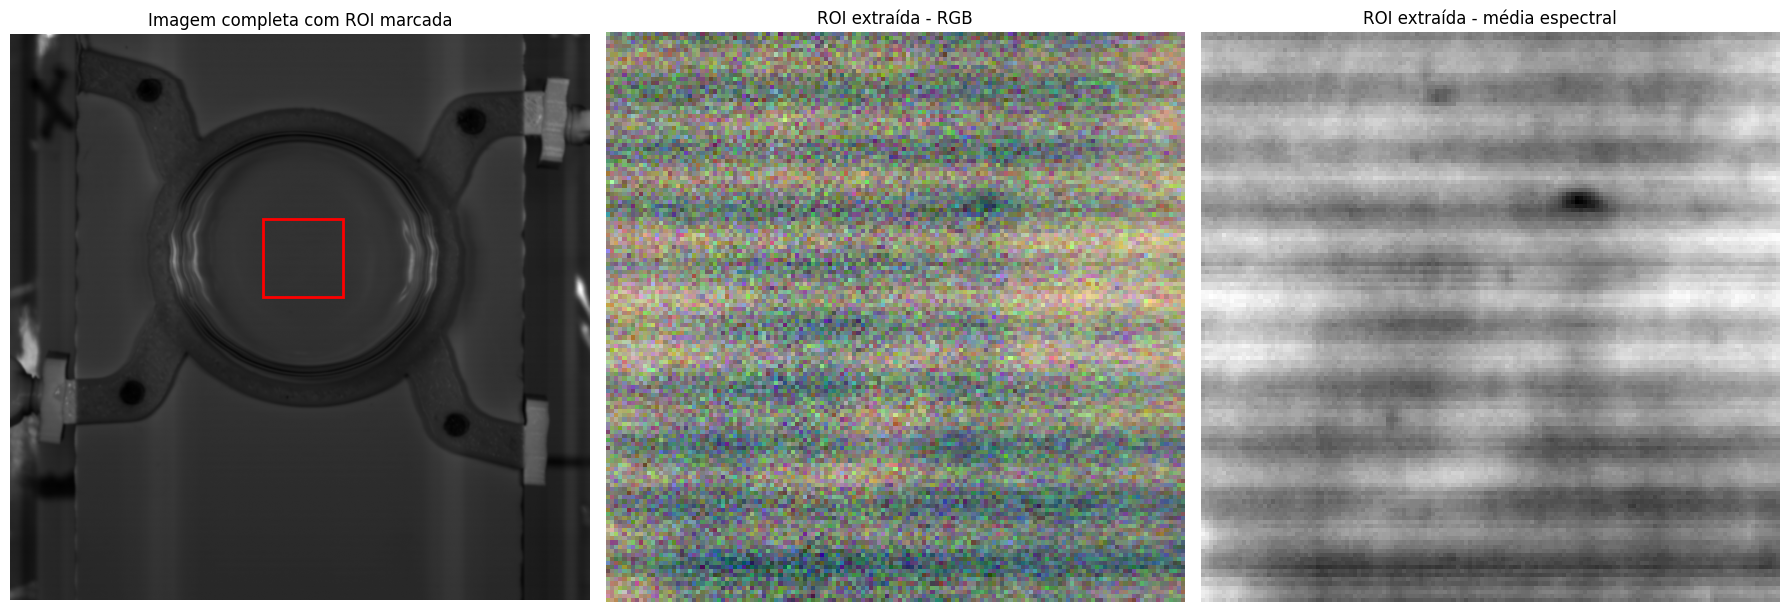

In [119]:
#Processar a ROI selecionada
click1, click2 = right_clicks[0], right_clicks[1]
roi, frame_data, (x_min, y_min, x_max, y_max) = extract_roi(corrected_data, click1, click2)

print("ROI shape:", roi.shape)

roi_rgb = get_rgb(roi, bands=[100, 55, 18])
roi_mean = np.mean(roi, axis=2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Painel 1: imagem completa com ROI marcada
axes[0].imshow(frame_data, cmap='gray')
rect = Rectangle(
    (x_min, y_min),
    x_max - x_min,
    y_max - y_min,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)
axes[0].add_patch(rect)
axes[0].set_title('Imagem completa com ROI marcada')
axes[0].axis('off')

# Painel 2: ROI em RGB
axes[1].imshow(roi_rgb)
axes[1].set_title('ROI extraída - RGB')
axes[1].axis('off')

# Painel 3: ROI em média espectral
axes[2].imshow(roi_mean, cmap='gray')
axes[2].set_title('ROI extraída - média espectral')
axes[2].axis('off')

plt.tight_layout()
plt.show()

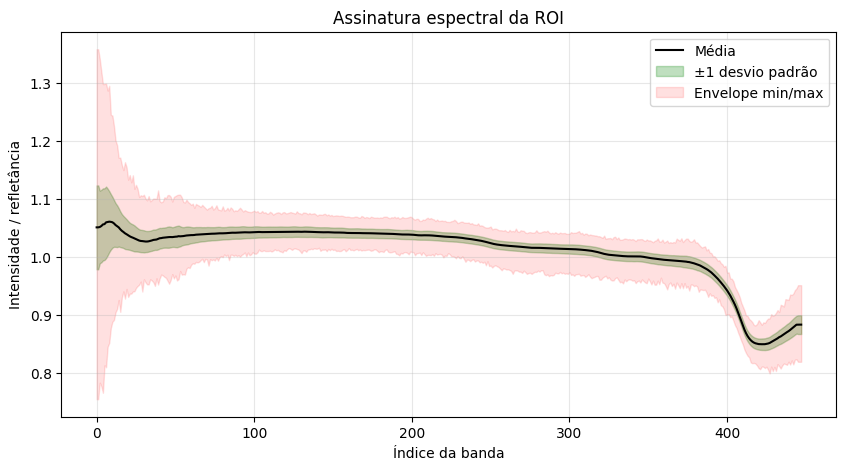

In [120]:
pixels = roi.reshape(-1, roi.shape[2])   # (n_pixels, 448)

mean_spectrum = np.mean(pixels, axis=0)
std_spectrum = np.std(pixels, axis=0)
min_spectrum = np.min(pixels, axis=0)
max_spectrum = np.max(pixels, axis=0)

bands_idx = np.arange(roi.shape[2])

plt.figure(figsize=(10, 5))
plt.plot(bands_idx, mean_spectrum, color='black', label='Média')
plt.fill_between(
    bands_idx,
    mean_spectrum - std_spectrum,
    mean_spectrum + std_spectrum,
    color='green',
    alpha=0.25,
    label='±1 desvio padrão'
)
plt.fill_between(
    bands_idx,
    min_spectrum,
    max_spectrum,
    color='red',
    alpha=0.12,
    label='Envelope min/max'
)

plt.xlabel('Índice da banda')
plt.ylabel('Intensidade / refletância')
plt.title('Assinatura espectral da ROI')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


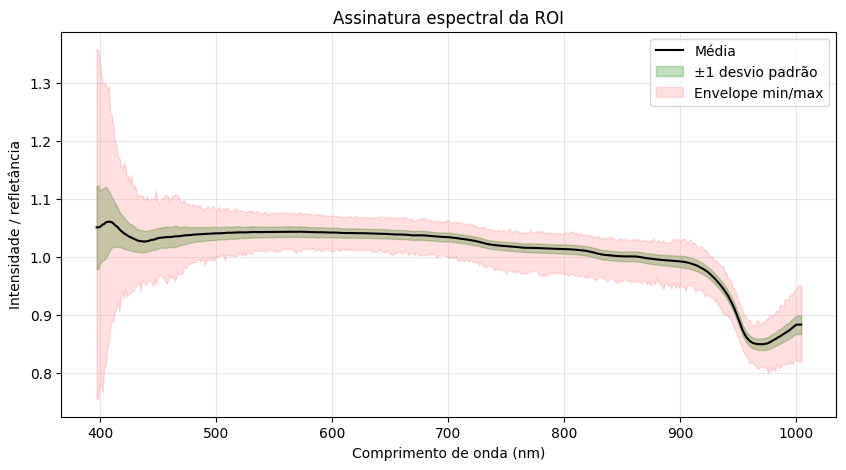

In [121]:
wavelengths = np.array(data_ref.bands.centers)

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, mean_spectrum, color='black', label='Média')
plt.fill_between(
    wavelengths,
    mean_spectrum - std_spectrum,
    mean_spectrum + std_spectrum,
    color='green',
    alpha=0.25,
    label='±1 desvio padrão'
)
plt.fill_between(
    wavelengths,
    min_spectrum,
    max_spectrum,
    color='red',
    alpha=0.12,
    label='Envelope min/max'
)

plt.xlabel('Comprimento de onda (nm)')
plt.ylabel('Intensidade / refletância')
plt.title('Assinatura espectral da ROI')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
df_spectrum = pd.DataFrame(
    columns=wavelengths, data=[mean_spectrum]
)


,397.01
0,1.051401
